# Cruise Fuel Prediction using XGBoost, Physics, Weather, and Time Features

Goal:
Predict fuel consumption during the cruise phase using ADS-B phase features, selected physics features, and time features.


### Imports


In [1]:
from sklearn.model_selection import TimeSeriesSplit, ParameterSampler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import numpy as np
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt


### Load feature dataset

The cruise-phase feature table is loaded from the SQLite database.
Each row represents one flight with aggregated phase-level features.

Target variable:
- cruise_fuel

Input features:
- `alt_gain_m_cruise`: altitude gained during cruise
- `time_s_cruise`: cruise duration
- `dist_m_cruise`: distance flown during cruise
- `alt_loss_m_cruise`: altitude lost during cruise
- `mean_alt_m_cruise`: mean altitude during cruise
- `max_alt_m_cruise`: maximum altitude during cruise
- `mean_vr_mps_cruise`: mean vertical rate during cruise
- `mean_gs_mps_cruise`: mean ground speed during cruise
- `p95_gs_mps_cruise`: 95th percentile ground speed during cruise
- `std_gs_mps_cruise`: ground speed variability during cruise
- `p95_abs_vr_mps_cruise`: 95th percentile absolute vertical rate during cruise
- `turn_sum_deg_cruise`: cumulative heading change during cruise
- `great_circle_distance`: route distance between departure and arrival airports
- `n_points_cruise`: number of ADS-B observations assigned to cruise
- `gradient_cruise`: ratio of altitude change to cruise distance traveled
- `turn_rate_degps_cruise`: cumulative heading change divideded by cruise duration
- departure time features




In [2]:
DB_PATH = "../../opensky.sqlite"
FEATURE_TABLE = "config3"

YEAR = 2022

TARGET = "cruise_fuel"

FEATURES = [
    "alt_gain_m_cruise",
    "time_s_cruise",
    "dist_m_cruise",
    "alt_loss_m_cruise",
    "mean_alt_m_cruise",
    "max_alt_m_cruise",
    "mean_vr_mps_cruise",
    "mean_gs_mps_cruise",
    "p95_gs_mps_cruise",
    "std_gs_mps_cruise",
    "p95_abs_vr_mps_cruise",
    "turn_sum_deg_cruise",
    "great_circle_distance",
    "n_points_cruise",

    #"spec_pe_cruise",
    #"spec_ke_cruise",
    "gradient_cruise",
    "turn_rate_degps_cruise",
    #"dyn_press_cruise",
    #"drag_work_cruise",

    # time features
    "dep_dow_sin", "dep_dow_cos",
    "dep_month_sin", "dep_month_cos"
]


### Reconstruct Flight Datetime

The dataset does not contain an explicit `flight_dt` column.
Instead, the flight timestamp is reconstructed from the `flight_id`,
which follows the format:

    icao24-callsign-mm-dd-hh-mm

The flight date and time are parsed and converted into a proper datetime object (`flight_dt`).
This timestamp is later used for the temporal train/test split, helping avoid leakage from future flights into model training.

We also define a custom MAPE helper and a `make_X` helper for preparing model inputs.


In [3]:
def add_datetime_from_flight_id(df, year=YEAR):
    parts = df["flight_id"].str.rsplit("-", n=4, expand=True)
    parts.columns = ["prefix", "month", "day", "hour", "minute"]

    out = df.copy()
    out["month"] = pd.to_numeric(parts["month"], errors="coerce").astype("Int64")
    out["day"] = pd.to_numeric(parts["day"], errors="coerce").astype("Int64")
    out["hour"] = pd.to_numeric(parts["hour"], errors="coerce").astype("Int64")
    out["minute"] = pd.to_numeric(parts["minute"], errors="coerce").astype("Int64")

    out["flight_dt"] = pd.to_datetime(
        dict(
            year=year,
            month=out["month"],
            day=out["day"],
            hour=out["hour"],
            minute=out["minute"],
        ),
        errors="coerce",
    )
    return out


def mape(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (np.abs(y_true) > eps)
    if not mask.any():
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def make_X(data):
    return data[FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0.0)


### Load feature table


In [4]:
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql(f'SELECT * FROM "{FEATURE_TABLE}"', conn)
conn.close()

required = ["flight_id", "icao24", "time_s_cruise", "dist_m_cruise", TARGET] + FEATURES
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in feature table: {missing}")

df = add_datetime_from_flight_id(df, YEAR)
df = df[df["flight_dt"].notna()].copy()
df["month"] = df["flight_dt"].dt.month

print("Rows total:", len(df))


Rows total: 14015


### Filter Valid Cruise Observations

We restrict the dataset to flights with:

- Non-missing cruise fuel (`cruise_fuel`)
- Positive cruise fuel
- Positive cruise duration
- Positive cruise distance

This ensures that the model is trained only on meaningful cruise-phase observations.


In [5]:
df2 = df[df[TARGET].notna()].copy()
df2 = df2[np.isfinite(df2[TARGET])].copy()
df2 = df2[df2[TARGET] > 0.0].copy()
df2 = df2[df2["time_s_cruise"].fillna(0.0) > 0.0].copy()
df2 = df2[df2["dist_m_cruise"].fillna(0.0) > 0.0].copy()

df2["month"] = df2["flight_dt"].dt.month

print("Filtered rows:", len(df2))


Filtered rows: 11881


### Temporal Data Split

We split the dataset into:

- Development period: January-October
- Test period: November-December

The development period is used for time-based cross-validation and hyperparameter selection.

The test period remains completely unseen until final evaluation to ensure an unbiased estimate of model performance.


In [6]:
dev = df2[df2["month"] <= 10].copy()   # Jan-Oct
test = df2[df2["month"] >= 11].copy()  # Nov-Dec, valid cruise rows for model evaluation
test_all = df[df["month"] >= 11].copy()  # Nov-Dec, all flights for total-fuel export

print("Development:", len(dev), "| Test:", len(test), "| Test all:", len(test_all))


Development: 8782 | Test: 3099 | Test all: 3505


### Expanding-Window Cross-Validation with Early Stopping

The January-October development data are sorted by departure time and split using `TimeSeriesSplit`.

For each split, the model is trained on earlier flights and validated on the next time period. The training window expands for each split, so the model is always evaluated on future data.

A random search with 50 trials is used to tune the XGBoost hyperparameters. For each trial, the last 20% of the training window is used for early stopping. Training stops if the validation MAE does not improve for 200 boosting rounds.

The hyperparameter combination with the lowest mean validation MAE is selected. The November-December test set is kept separate and used only for final evaluation.


In [7]:
df_cv = dev.sort_values("flight_dt").reset_index(drop=True)

tscv = TimeSeriesSplit(n_splits=5)

param_space = {
    "learning_rate": [0.01, 0.02, 0.03, 0.05],
    "max_depth": [3, 4, 5, 6],
    "min_child_weight": [1, 2, 3, 5],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "reg_lambda": [0.5, 1, 2, 5],
    "reg_alpha": [0, 0.01, 0.1, 0.5],
    "gamma": [0, 0.1, 0.5, 1],
}

N_TRIALS = 50

param_list = list(ParameterSampler(
    param_space,
    n_iter=N_TRIALS,
    random_state=42
))

results = []

for trial, params in enumerate(param_list, start=1):
    fold_mae = []
    fold_rmse = []
    fold_mape = []
    fold_r2 = []
    best_iters = []

    for train_idx, val_idx in tscv.split(df_cv):
        train_fold = df_cv.iloc[train_idx].copy()
        val_fold = df_cv.iloc[val_idx].copy()

        split = int(len(train_fold) * 0.8)
        tr = train_fold.iloc[:split]
        es = train_fold.iloc[split:]

        X_tr = make_X(tr)
        y_tr = tr[TARGET].to_numpy()

        X_es = make_X(es)
        y_es = es[TARGET].to_numpy()

        X_val = make_X(val_fold)
        y_val = val_fold[TARGET].to_numpy()

        model = XGBRegressor(
            n_estimators=12000,
            objective="reg:gamma",
            eval_metric="mae",
            early_stopping_rounds=200,
            random_state=42,
            n_jobs=-1,
            **params
        )

        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_es, y_es)],
            verbose=False
        )

        pred = model.predict(X_val)

        fold_mae.append(mean_absolute_error(y_val, pred))
        fold_rmse.append(np.sqrt(mean_squared_error(y_val, pred)))
        fold_mape.append(mape(y_val, pred))
        fold_r2.append(r2_score(y_val, pred))
        best_iters.append(model.best_iteration)

    results.append({
        **params,
        "mean_mae": np.mean(fold_mae),
        "std_mae": np.std(fold_mae),
        "mean_rmse": np.mean(fold_rmse),
        "mean_mape": np.mean(fold_mape),
        "mean_r2": np.mean(fold_r2),
        "avg_best_iter": int(np.mean(best_iters)),
    })

results_df = pd.DataFrame(results).sort_values("mean_mae")
best_row = results_df.iloc[0]

print(best_row)


subsample             0.900000
reg_lambda            2.000000
reg_alpha             0.010000
min_child_weight      3.000000
max_depth             4.000000
learning_rate         0.050000
gamma                 0.000000
colsample_bytree      0.700000
mean_mae             37.258713
std_mae              11.477078
mean_rmse            86.993171
mean_mape            13.217912
mean_r2               0.953441
avg_best_iter       377.000000
Name: 37, dtype: float64


### Final Model Training and Evaluation

After cross-validation, the selected hyperparameters and the average best number of boosting rounds are extracted from the best-performing trial.

The final model is trained on the full January-October development set using the selected hyperparameters and fixed number of estimators. No early stopping is used at this stage, since the number of boosting rounds has already been selected during cross-validation.

The final model is then evaluated on the November-December test set, which was not used during cross-validation or hyperparameter tuning.

Performance is evaluated using MAE, RMSE, MAPE, and $R^2$.


In [8]:
best_params = {
    "learning_rate": best_row["learning_rate"],
    "max_depth": int(best_row["max_depth"]),
    "min_child_weight": best_row["min_child_weight"],
    "subsample": best_row["subsample"],
    "colsample_bytree": best_row["colsample_bytree"],
    "reg_lambda": best_row["reg_lambda"],
    "reg_alpha": best_row["reg_alpha"],
    "gamma": best_row["gamma"],
}

final_model = XGBRegressor(
    n_estimators=int(best_row["avg_best_iter"]),
    objective="reg:gamma",
    eval_metric="mae",
    random_state=42,
    n_jobs=-1,
    **best_params
)

X_dev = make_X(dev)
y_dev = dev[TARGET].to_numpy()

final_model.fit(X_dev, y_dev)

X_test = make_X(test)
y_test = test[TARGET].to_numpy()
pred_test = final_model.predict(X_test)

test_mae = mean_absolute_error(y_test, pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))
test_mape = mape(y_test, pred_test)
test_r2 = r2_score(y_test, pred_test)

print(f"Test MAE : {test_mae:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test MAPE: {test_mape:.2f}%")
print(f"Test R^2: {test_r2:.3f}")


Test MAE : 26.18
Test RMSE: 43.39
Test MAPE: 14.29%
Test R^2: 0.982


### Feature importance (sanity check)

Feature importance is extracted from the trained XGBoost model to inspect which cruise-phase variables contributed most to the predictions.

This is used as a sanity check to verify that physically meaningful variables dominate the model, and not as a causal interpretation.


In [9]:
imp = pd.Series(final_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
imp


time_s_cruise             0.427122
n_points_cruise           0.302560
dist_m_cruise             0.194719
great_circle_distance     0.057555
gradient_cruise           0.003925
max_alt_m_cruise          0.001643
dep_month_sin             0.001578
alt_loss_m_cruise         0.001337
p95_abs_vr_mps_cruise     0.001111
turn_sum_deg_cruise       0.001020
p95_gs_mps_cruise         0.000923
mean_alt_m_cruise         0.000909
dep_month_cos             0.000877
mean_gs_mps_cruise        0.000835
mean_vr_mps_cruise        0.000813
std_gs_mps_cruise         0.000757
dep_dow_sin               0.000702
turn_rate_degps_cruise    0.000668
alt_gain_m_cruise         0.000503
dep_dow_cos               0.000442
dtype: float32

### Generate csv file with flight id and corresponding fuel prediction

Finally, we export predictions for every November-December test flight for downstream total-fuel aggregation.

The output file contains:
- Flight identifier
- True cruise fuel, with missing phase fuel set to 0
- Predicted cruise fuel, with absent or invalid phase rows set to 0


In [10]:
from pathlib import Path

csv_folder = Path("csv_files")
csv_folder.mkdir(parents=True, exist_ok=True)

file_path = csv_folder / "pred_physics_weather_cruise.csv"

PHASE = "cruise"
true_col = f"true_physics_weather_{PHASE}"
pred_col = f"pred_physics_weather_{PHASE}"

export_df = test_all[["flight_id", TARGET]].copy()
export_df[true_col] = export_df[TARGET].fillna(0.0)
export_df[pred_col] = 0.0

valid_phase = (
    test_all[TARGET].notna()
    & np.isfinite(test_all[TARGET])
    & (test_all[TARGET] > 0.0)
    & (test_all["time_s_cruise"].fillna(0.0) > 0.0)
    & (test_all["dist_m_cruise"].fillna(0.0) > 0.0)
)

if valid_phase.any():
    export_df.loc[valid_phase, pred_col] = final_model.predict(make_X(test_all.loc[valid_phase]))

pred_df = export_df[["flight_id", true_col, pred_col]]

pred_df.to_csv(file_path, index=False)
print("Wrote:", file_path)


Wrote: csv_files/pred_physics_weather_cruise.csv


### Plot Test Predictions



In [11]:
def run_regression_report(
    model,
    X_test,
    y_test,
    y_pred,
    model_name="Model"
):

    #Pred vs Actual
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.3)

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Perfect prediction")

    m, b = np.polyfit(y_test, y_pred, 1)
    x_line = np.linspace(min_val, max_val, 100)
    plt.plot(x_line, m*x_line + b, label=f"Regression: y={m:.2f}x+{b:.2f}")

    plt.title(f"{model_name}: Predicted vs Actual")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.legend()
    plt.show()


    # Feature importance
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        idx = np.argsort(importances)[::-1][:15]

        features = [X_test.columns[i] for i in idx]

        plt.figure(figsize=(6,6))
        plt.barh(features[::-1], importances[idx][::-1])
        plt.title(f"{model_name}: Feature importance")
        plt.show()


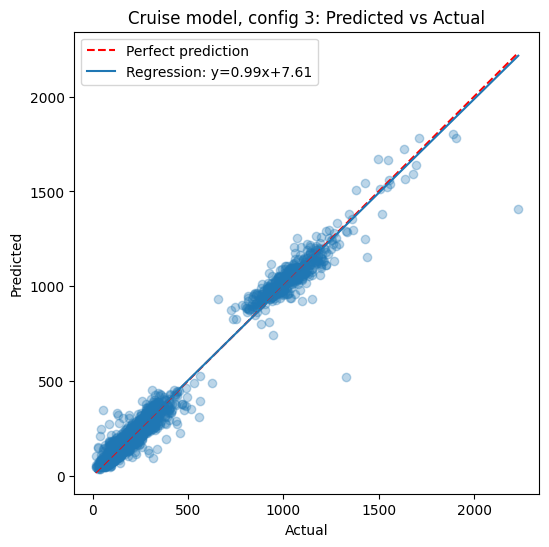

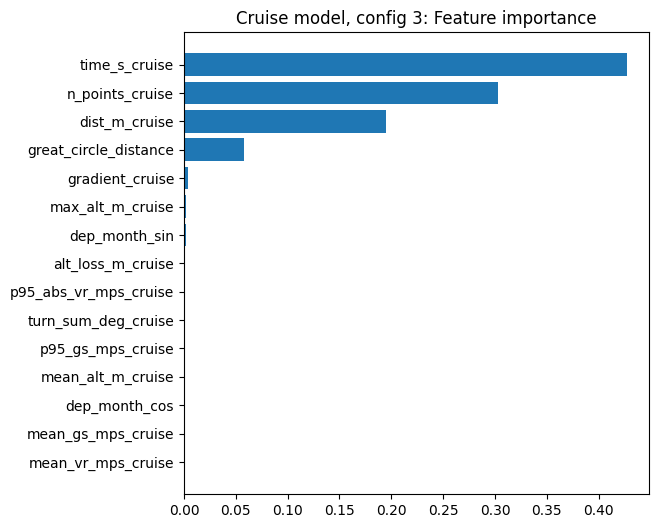

In [12]:
X_test_df = make_X(test)

run_regression_report(
    model=final_model,
    X_test=X_test,
    y_test=y_test,
    y_pred=pred_test,
    model_name="Cruise model, config 3"
)